# 232 Group Project Part 2: Data Exploration

### 1. GitHub Repository Setup
Milestone 2 Branch: https://github.com/rowheaton/ragus-wheaton-iribe-232/tree/main/milestone2

**Import Packages**

In [25]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, LongType, DoubleType, FloatType
from pyspark.sql.functions import col, count, length,countDistinct, broadcast, min as spark_min, max as spark_max,avg, stddev, approx_count_distinct
import requests
import pandas as pd
import matplotlib.pyplot as plt

### 2. SDSC Expanse Environment Setup

8 total cores and 128 GB total memory, reserving 2 GB for the Spark driver. Executor instances = 8 - 1 = 7. Executor memory = (128 - 2) / 7 = 18 GB per executor. Spark is configured with 7 executor instances and 18 GB executor memory.

Calculated executer memory is ~17.7GB but we reduced it to 16 GB and allocated 2 GB memory overhead per executor to prevent memory exhaustion during heavy operations.

In [26]:
total_cores = 8
total_memory_gb = 128
driver_memory_gb = 4   

executor_instances = total_cores - 1
raw_executor_memory = (total_memory_gb - driver_memory_gb) / executor_instances

executor_memory_gb = 16
executor_overhead_gb = 2

print(f"Executor instances = {executor_instances}")
print(f"Raw executor memory = {raw_executor_memory:.2f} GB")
print(f"Configured executor memory = {executor_memory_gb} GB (+{executor_overhead_gb} GB overhead)")

spark = (
    SparkSession.builder
    .appName("MusicBrainz")
    .config("spark.driver.memory", f"{driver_memory_gb}g")
    .config("spark.executor.instances", executor_instances)
    .config("spark.executor.memory", f"{executor_memory_gb}g")
    .config("spark.executor.memoryOverhead", f"{executor_overhead_gb}g")
    .config("spark.sql.shuffle.partitions", executor_instances * total_cores)
    .getOrCreate()
)

sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

response = requests.get(url)
executors = response.json()

spark_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spark_df['maxMemory_GB'] = (spark_df['maxMemory'] / (1024**3)).round(2)
spark_df

Executor instances = 7
Raw executor memory = 17.71 GB
Configured executor memory = 16 GB (+2 GB overhead)


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,2388236697,0,True,2.22


### 3. Data Exploration using Spark

**Define Variables**

In [27]:
MBDUMP = "/expanse/lustre/projects/uci157/rwheaton1/mbdump"

In [28]:
def peek(df, n=5):
    return display(df.limit(n).toPandas())

**Define Schemas**

In [29]:
artist_schema = StructType([
    StructField("id",               IntegerType(),   True),
    StructField("gid",              StringType(),    True),
    StructField("name",             StringType(),    True),
    StructField("sort_name",        StringType(),    True),
    StructField("begin_date_year",  IntegerType(),   True),
    StructField("begin_date_month", IntegerType(),   True),
    StructField("begin_date_day",   IntegerType(),   True),
    StructField("end_date_year",    IntegerType(),   True),
    StructField("end_date_month",   IntegerType(),   True),
    StructField("end_date_day",     IntegerType(),   True),
    StructField("type",             IntegerType(),   True),
    StructField("area",             IntegerType(),   True),
    StructField("gender",           IntegerType(),   True),
    StructField("comment",          StringType(),    True),
    StructField("edits_pending",    IntegerType(),   True),
    StructField("last_updated",     StringType(),    True),
    StructField("ended",            StringType(),    True),
    StructField("begin_area",       IntegerType(),   True),
    StructField("end_area",         IntegerType(),   True),
])
instrument_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
label_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("sort_name",     StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("area",          IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
    StructField("ended",         StringType(),  True),
])
genre_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
area_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
tag_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("ref_count",     IntegerType(), True),
])
gender_schema = StructType([
    StructField("id",   IntegerType(), True),
    StructField("name", StringType(),  True),
])
release_group_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("artist_credit", IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
l_artist_label_schema = StructType([
    StructField("id",        IntegerType(), True),
    StructField("link",      IntegerType(), True),
    StructField("entity0",   IntegerType(), True),  # artist
    StructField("entity1",   IntegerType(), True),  # label
])
l_artist_release_group_schema = StructType([
    StructField("id",        IntegerType(), True),
    StructField("link",      IntegerType(), True),
    StructField("entity0",   IntegerType(), True),  # artist
    StructField("entity1",   IntegerType(), True),  # release_group
])
label_tag_schema = StructType([
    StructField("label", IntegerType(), True),
    StructField("tag",   IntegerType(), True),
    StructField("count", IntegerType(), True),
])
l_artist_genre_schema = StructType([
    StructField("artist", IntegerType(), True),
    StructField("genre",  IntegerType(), True),
    StructField("count",  IntegerType(), True),
])
l_artist_artist_schema = StructType([
    StructField("id",      IntegerType(), True),
    StructField("link",    IntegerType(), True),
    StructField("entity0", IntegerType(), True),
    StructField("entity1", IntegerType(), True),
])
release_group_tag_schema = StructType([
    StructField("release_group", IntegerType(), True),
    StructField("tag",           IntegerType(), True),
    StructField("count",         IntegerType(), True),
])
artist_tag_schema = StructType([
    StructField("artist", IntegerType(), True),
    StructField("tag",    IntegerType(), True),
    StructField("count",  IntegerType(), True),
])
artist_credit_schema = StructType([
    StructField("id",         IntegerType(), True),
    StructField("name",       StringType(),  True),
    StructField("artist_count", IntegerType(), True),
])
artist_credit_name_schema = StructType([
    StructField("artist_credit", IntegerType(), True),
    StructField("position",      IntegerType(), True),
    StructField("artist",        IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("join_phrase",   StringType(),  True),
])
l_artist_instrument_schema = StructType([
    StructField("id",      IntegerType(), True),
    StructField("link",    IntegerType(), True),
    StructField("entity0", IntegerType(), True),  # artist
    StructField("entity1", IntegerType(), True),  # instrument
])
schemas = {
    "artist": artist_schema,
    "instrument": instrument_schema,
    "label": label_schema,
    "genre": genre_schema,
    "area": area_schema,
    "tag": tag_schema,
    "gender": gender_schema,
    "release_group": release_group_schema,

    "l_artist_label": l_artist_label_schema,
    "l_artist_release_group": l_artist_release_group_schema,
    "label_tag": label_tag_schema,
    "l_artist_genre": l_artist_genre_schema,
    "l_artist_artist": l_artist_artist_schema,
    "release_group_tag": release_group_tag_schema,
    "artist_tag": artist_tag_schema,
    "artist_credit": artist_credit_schema,
    "artist_credit_name": artist_credit_name_schema,
    "l_artist_instrument": l_artist_instrument_schema,
}

**Table Details**

In [30]:
dfs = {}

for table_name, schema in schemas.items():
    print(f"\n==============================")
    print(f"Loading table: {table_name}")
    print(f"==============================")

    df = (
        spark.read
        .option("sep", "\t")
        .option("nullValue", r"\N")
        .option("header", "false")
        .option("quote", "")
        .option("escape", "")
        .schema(schema)
        .csv(f"{MBDUMP}/{table_name}")
    )

    dfs[table_name] = df
    
    row_count = df.count()
    print(f"Total {table_name} rows: {row_count}")
    duplicate_count = row_count - df.dropDuplicates().count()
    print(f"Duplicate rows in {table_name}: {duplicate_count}")

    print("=== SCHEMA ===")
    df.printSchema()

    print("=== PEEK ===")
    peek(df)


Loading table: artist
Total artist rows: 2853154
Duplicate rows in artist: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- sort_name: string (nullable = true)
 |-- begin_date_year: integer (nullable = true)
 |-- begin_date_month: integer (nullable = true)
 |-- begin_date_day: integer (nullable = true)
 |-- end_date_year: integer (nullable = true)
 |-- end_date_month: integer (nullable = true)
 |-- end_date_day: integer (nullable = true)
 |-- type: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- comment: string (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- ended: string (nullable = true)
 |-- begin_area: integer (nullable = true)
 |-- end_area: integer (nullable = true)

=== PEEK ===


,id,gid,name,sort_name,begin_date_year,begin_date_month,begin_date_day,end_date_year,end_date_month,end_date_day,type,area,gender,comment,edits_pending,last_updated,ended,begin_area,end_area
0,2252039,fadeb38c-833f-40bc-9d8c-a6383b38b1be,Доктор Сатана,Доктор Сатана,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2021-11-23 07:08:52.479537+00,f,NaN,NaN
1,371203,49add228-eac5-4de8-836c-d75cde7369c3,Pete Moutso,"Moutso, Pete",NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,None,0,None,f,NaN,NaN
2,3087346,dfdce491-133d-4e9f-9e48-795587e181b0,UNlT,UNlT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2025-09-14 23:53:28.004798+00,f,NaN,NaN
3,2851271,165a49a0-2b3b-4078-a3c1-905afdc07c0a,Babyglock,Babyglock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2024-10-19 03:33:55.474151+00,f,NaN,NaN
4,145773,7b4a548e-a01a-49b7-82e7-b49efeb9732c,Aric Leavitt,"Leavitt, Aric",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,None,f,NaN,NaN



Loading table: instrument
Total instrument rows: 1056
Duplicate rows in instrument: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: integer (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)

=== PEEK ===


,id,gid,name,type,edits_pending,last_updated
0,687,c1dbb66d-2356-417a-81ad-f688fee33257,guitarrón mexicano,2,0,2015-02-15 07:32:32.570132+00
1,695,2474c241-d267-433a-a404-688b13c51d11,jouhikko,2,0,2015-02-25 19:47:04.610414+00
2,701,c0cc863c-ea65-4b8a-b365-28b81b72d846,friction idiophone,3,0,2015-02-26 10:28:49.766548+00
3,706,5f9bb15a-738f-48bb-8676-55e62547726f,doshpuluur,2,0,2015-02-28 00:15:24.010482+00
4,707,9bae90ea-9729-4c30-bd3e-f8319cdf4051,igil,2,0,2015-02-28 23:39:39.01131+00



Loading table: label
Total label rows: 334811
Duplicate rows in label: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- sort_name: string (nullable = true)
 |-- type: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- comment: string (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- ended: string (nullable = true)

=== PEEK ===


...

,id,name,artist_count
0,4229350,"Jean-Paul Fouchécourt, Yvonne Naef, Saito Kine...",4
1,3320885,The Turns,1
2,3320887,Son.Sine,1
3,3431907,Auggië,1
4,3435757,Joe Innes & the Cavalcade,1



Loading table: artist_credit_name
Total artist_credit_name rows: 6801672
Duplicate rows in artist_credit_name: 0
=== SCHEMA ===
root
 |-- artist_credit: integer (nullable = true)
 |-- position: integer (nullable = true)
 |-- artist: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- join_phrase: string (nullable = true)

=== PEEK ===


,artist_credit,position,artist,name,join_phrase
0,578352,0,578352,Gustav Ruppke,None
1,273232,0,273232,Zachary,None
2,153193,0,153193,The High Level Ranters,None
3,32262,0,32262,Georges Brassens,None
4,1389968,0,1171184,Harvard of the South,None



Loading table: l_artist_instrument
Total l_artist_instrument rows: 96
Duplicate rows in l_artist_instrument: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- link: integer (nullable = true)
 |-- entity0: integer (nullable = true)
 |-- entity1: integer (nullable = true)

=== PEEK ===


,id,link,entity0,entity1
0,1,311992,1218252,121
1,2,312066,1395197,19
2,24,393478,1261488,808
3,4,312066,1395235,118
4,5,312066,1395197,21


**Explore and Summarize Columns**

The below section creates a profiling loop that classifies columns by their role and then summarizes them. The MusicBrainz dataset has a lot of IDs and relationship table columns so we need to sift through it and figure out which numeric columns should be summarized like a continuous variable verses an ID. The loop reports nulls, distinct counts, duplicates, categorical frequencies, numeric summaries, and foreign key uniqueness depending on the column type. 

We started by idetifying the primary keys, global ID, forgein key, date part, boolean, text descriptor and count measure clumns for each of the tables we chose.

We then created the function __get_column_role__ that classifies a given column's role/data type. This function is executed in the for loop which loops through each table's columns to summarize them based on their role which was assigned in the __get_column_role__ function. 

- ID (or id-ish) columns like id, gid, entity0, and entity1, the loop returns missing values, distinct counts, and if foreign keys match the referenced table (not sure if this is actually working how we want it to so take this part with a grain of salt). Not showing frequency distributions bc most ID values are unique and a top 10 count table wouldnt be value add

- Categorical columns are summarized using value counts and percentages to show which values are most common and whether the distribution is balanced or skewed

- Numeric/count columns are summarized with count, mean, standard deviation, min, quartiles, and max

- High-cardinality text columns, like names or UUIDs, get summarized with distinct counts and length stats instead of value counts bc there are way too many unique values

In [31]:
primary_key_cols = {"id"}
global_id_cols = {"gid"}
foreign_key_map = {
    "artist": {
        "type": ("artist_type", "id"),
        "area": ("area", "id"),
        "gender": ("gender", "id"),
        "begin_area": ("area", "id"),
        "end_area": ("area", "id"),
    },
    "instrument": {
        "type": ("instrument_type", "id"),
    },
    "label": {
        "type": ("label_type", "id"),
        "area": ("area", "id"),
    },
    "release_group": {
        "type": ("release_group_primary_type", "id"),
        "artist_credit": ("artist_credit", "id"),
    },

    "artist_credit_name": {
        "artist_credit": ("artist_credit", "id"),
        "artist": ("artist", "id"),
    },

    "label_tag": {
        "label": ("label", "id"),
        "tag": ("tag", "id"),
    },
    "artist_tag": {
        "artist": ("artist", "id"),
        "tag": ("tag", "id"),
    },
    "l_artist_genre": {
        "artist": ("artist", "id"),
        "genre": ("genre", "id"),
    },
    "release_group_tag": {
        "release_group": ("release_group", "id"),
        "tag": ("tag", "id"),
    },

    "l_artist_label": {
        "link": ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("label", "id"),
    },
    "l_artist_release_group": {
        "link": ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("release_group", "id"),
    },
    "l_artist_artist": {
        "link": ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("artist", "id"),
    },
    "l_artist_instrument": {
        "link": ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("instrument", "id"),
    },
}
date_part_cols = {"begin_date_year", "begin_date_month", "begin_date_day", "end_date_year", "end_date_month", "end_date_day"}
boolean_like_cols = {"ended"}
text_descriptor_cols = {"name", "sort_name", "comment", "join_phrase", "last_updated"}
count_measure_cols = {"count", "ref_count", "artist_count", "edits_pending", "position"}


In [32]:
def get_column_role(table_name, column_name, row_count, distinct_count):
    distinct_ratio = distinct_count / row_count if row_count else 0

    table_fk = foreign_key_map.get(table_name, {})

    rules = [
                (column_name in primary_key_cols, "primary_key"),
                (column_name in global_id_cols, "global_identifier"),
                (column_name in table_fk, "foreign_key"),
                (column_name in date_part_cols, "date_part"),
                (column_name in boolean_like_cols, "boolean_like"),
                (column_name in count_measure_cols, "count_measure"),
            ]

    for condition, role in rules:
        if condition:
            return role

    if column_name in text_descriptor_cols:
        return "high_cardinality_text" if distinct_ratio > 0.9 else "categorical_text"

    if distinct_ratio > 0.9:
        return "identifier_like"

    if distinct_count <= 25:
        return "categorical"

    return "numeric_or_high_cardinality"

In [33]:
profile_rows = []

for table_name, df in dfs.items():
    print(f"\n\n==============================")
    print(f"TABLE: {table_name}")
    print(f"==============================")

    for field in df.schema.fields:
        column_name = field.name
        dtype = field.dataType.simpleString()

        missing_count = df.filter(col(column_name).isNull()).count()
        distinct_count = df.select(approx_count_distinct(col(column_name))).first()[0]
        distinct_ratio = distinct_count / row_count if row_count else 0

        role = get_column_role(table_name, column_name, row_count, distinct_count)

        print(f"\n--- {column_name} ({dtype}) ---")
        print(f"Role: {role}")
        print(f"Missing: {missing_count}")
        print(f"Distinct: {distinct_count}")
        print(f"Distinct ratio: {distinct_ratio:.4f}")

        summary = {
            "table": table_name,
            "column": column_name,
            "dtype": dtype,
            "role": role,
            "row_count": row_count,
            "missing_count": missing_count,
            "missing_pct": missing_count / row_count if row_count else None,
            "distinct_count": distinct_count,
            "distinct_ratio": distinct_ratio,
            "duplicate_rows_in_table": duplicate_count,
        }

        if role in ["primary_key", "global_identifier", "identifier_like"]:
            print("Summary: identifier column; frequency distributions are not meaningful.")

            if isinstance(field.dataType, StringType):
                df.select(
                    spark_min(length(col(column_name))).alias("min_length"),
                    spark_max(length(col(column_name))).alias("max_length")
                ).show()

        elif role == "foreign_key":
            summary["references"] = str(foreign_key_map[table_name].get(column_name))

        elif role in ["categorical", "categorical_text", "boolean_like", "date_part"]:
            print("Top values:")
            (
                df.groupBy(column_name)
                .count()
                .withColumn("pct", col("count") / row_count)
                .orderBy(col("count").desc())
                .show(10, truncate=False)
            )

        elif role in ["count_measure", "numeric_or_high_cardinality"]:
            print("Numeric summary:")
            df.select(column_name).summary(
                "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
            ).show()

        elif role == "high_cardinality_text":
            print("Summary: high-cardinality text; showing length stats instead of value counts.")
            df.select(
                spark_min(length(col(column_name))).alias("min_length"),
                spark_max(length(col(column_name))).alias("max_length"),
                avg(length(col(column_name))).alias("avg_length")
            ).show()

        profile_rows.append(summary)

profile_df = spark.createDataFrame(profile_rows)
profile_df.show(200, truncate=False)



TABLE: artist

--- id (int) ---
Role: primary_key
Missing: 0
Distinct: 2721707
Distinct ratio: 28351.1146
Summary: identifier column; frequency distributions are not meaningful.

--- gid (string) ---
Role: global_identifier
Missing: 0
Distinct: 2732481
Distinct ratio: 28463.3438
Summary: identifier column; frequency distributions are not meaningful.
+----------+----------+
|min_length|max_length|
+----------+----------+
|        36|        36|
+----------+----------+


--- name (string) ---
Role: high_cardinality_text
Missing: 0
Distinct: 2746120
Distinct ratio: 28605.4167
Summary: high-cardinality text; showing length stats instead of value counts.
+----------+----------+------------------+
|min_length|max_length|        avg_length|
+----------+----------+------------------+
|         1|      1018|12.070556303655534|
+----------+----------+------------------+


--- sort_name (string) ---
Role: high_cardinality_text
Missing: 0
Distinct: 2617494
Distinct ratio: 27265.5625
Summary: hig

### 4. Data Plots

**Artist Gender Pie Chart**

The following pie chart is created to illustrate the distribution of artists by gender in the dataset. We joined the artist and gender tables together using the gender foreign key and then counting the number of artists per gender group. In this pie chart, we see that a majority(approximately 76.5%) of artists are male while the second largest group is female(approximately 23%). There are a few small groups of gender classification that make up the remaining 0.5% but overall we can see that our data skews heavily to one gender.

In [35]:
# garbage collection (maybe overkill but we can adjust this later)
del (
    total_cores, total_memory_gb, driver_memory_gb, executor_instances,
    raw_executor_memory, executor_memory_gb, executor_overhead_gb,
    sc, url, response, executors, spark_df,
    artist_schema, instrument_schema, label_schema, genre_schema, area_schema,
    tag_schema, gender_schema, release_group_schema, l_artist_label_schema,
    l_artist_release_group_schema, label_tag_schema, l_artist_genre_schema,
    l_artist_artist_schema, release_group_tag_schema, artist_tag_schema,
    artist_credit_schema, artist_credit_name_schema, l_artist_instrument_schema,
    schemas,
    primary_key_cols, global_id_cols, foreign_key_map, date_part_cols,
    boolean_like_cols, text_descriptor_cols, count_measure_cols,
    get_column_role, profile_rows, profile_df,
    df, table_name, field, column_name, dtype, missing_count,
    distinct_count, distinct_ratio, role, summary, row_count, duplicate_count,
    MBDUMP
)
import gc; gc.collect()

4816

In [36]:
artistdf = dfs["artist"]
genderdf = dfs["gender"]

In [37]:
artists_by_gender = artistdf.join(
    genderdf,
    artistdf.gender == genderdf.id
).groupBy(
    genderdf.name.alias("gender")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
)
artists_by_gender.show()

+--------------+------+
|        gender| count|
+--------------+------+
|          Male|932192|
|        Female|280203|
|Not applicable|  2443|
|    Non-binary|  2237|
|         Other|  1787|
+--------------+------+



In [38]:
artist_gender = artists_by_gender.toPandas()

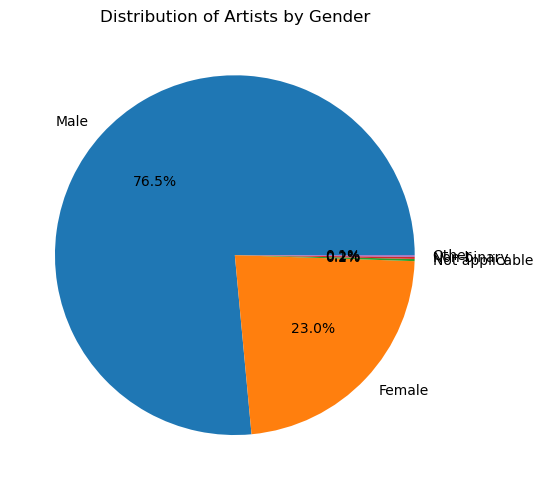

In [39]:
plt.figure(figsize=(8,5))
plt.pie(artist_gender["count"], labels = artist_gender["gender"], autopct ='%1.1f%%')
plt.title("Distribution of Artists by Gender")
plt.tight_layout()
plt.show()

**Instrument Type by Count Bar Chart**

This bar chart displays the distribution of instrument types used by artists. Using the instrument table we grouped by the type column and then counted each type. The chart shows that the most common instrument type is 2 followed by 1 and 3, while types 4,5,6,7 were less common having appeared less than 50 times each. These type values represent numeric identifiers, which could be further joined with the instrument_type table to obtain more descriptive labels for each category.

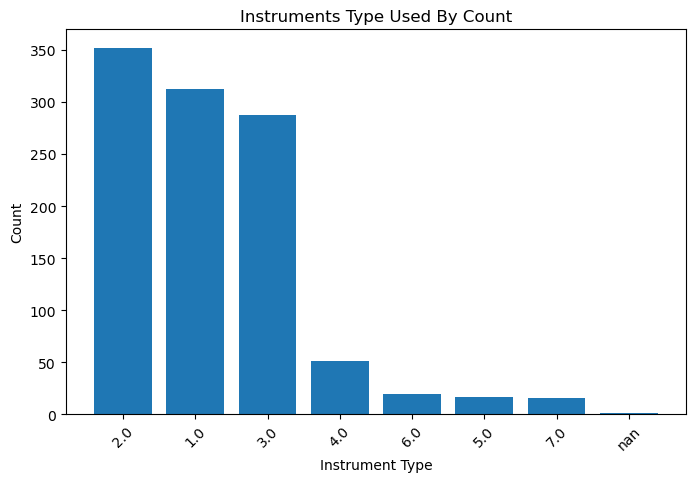

In [40]:
instrument_counts = dfs["instrument"].groupBy("type") \
    .agg(count("*").alias("count")) \
    .orderBy("count", ascending=False) \

instrument_dist = instrument_counts.toPandas()

plt.figure(figsize=(8,5))
plt.bar(instrument_dist["type"].astype(str), instrument_dist["count"])
plt.title("Instruments Type Used By Count")
plt.xlabel("Instrument Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Release Group Tag Bar Chart**

This horizontal bar chart uses the release_group_tag and tag tables to identify the top used tags for music. We did this to see what are the most common music genres tagged when music is released. The chart shows that electronic is the most common with over 500000 tags followed by rock. These two are the most common by far but interestingly the variations of rock like pop rock, indie rock, and alternative rock were some of the least used tags. This suggests that broader genre labels are used more often versus specialized classifications.

In [41]:
release_tags = dfs["release_group_tag"].join(
    dfs["tag"],
    dfs["release_group_tag"].tag == dfs["tag"].id
).groupBy(
    dfs["tag"].name.alias("tag")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)

release_tags.show()

+----------------+------+
|             tag| count|
+----------------+------+
|      electronic|507667|
|            rock|484442|
|             pop|260276|
|            jazz|128848|
|    experimental|123529|
|         ambient| 99194|
|         hip hop| 98943|
|            punk| 73250|
|       classical| 68145|
|        pop rock| 65195|
|      indie rock| 65022|
|          techno| 63127|
|           house| 60638|
|alternative rock| 59830|
|       downtempo| 50924|
+----------------+------+



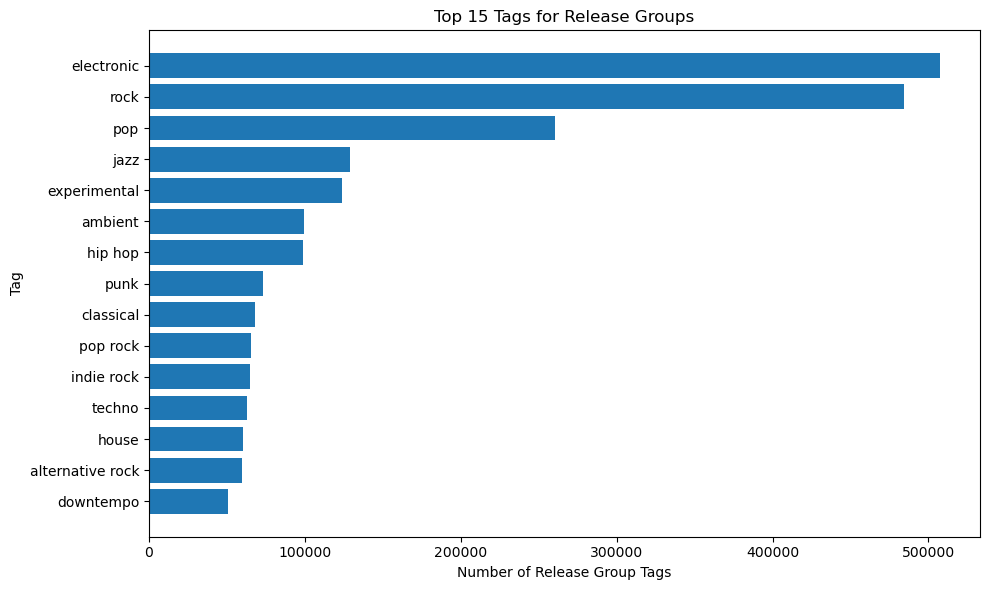

In [42]:
release_tags_pd = release_tags.toPandas()

plt.figure(figsize=(10,6))
plt.barh(release_tags_pd["tag"], release_tags_pd["count"])
plt.title("Top 15 Tags for Release Groups")
plt.xlabel("Number of Release Group Tags")
plt.ylabel("Tag")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Artist Label Count Bar Chart**

This bar chart shows the top 15 record labels with the highest number of artists linked to them. We joined the l_artist_label and label tables in order to count the number of artist per label.In the chart we see that "Audio Network" has the highest amount of artists linked to them by a wide margin. There are also only 7 record labels with 100 or more artists linked to them.Overall, the distribution suggests that a small number of labels are connected to many artists following a similar pattern to the other data visualized.

In [43]:
l_artist_label = dfs["l_artist_label"].select(
    col("entity1").alias("label_id")
)

labels = dfs["label"].select(
    col("id").alias("label_id"),
    col("name").alias("label")
)

label_artist_counts = (
    l_artist_label
    .join(broadcast(labels), on="label_id", how="inner")
    .groupBy("label")
    .agg(count("*").alias("artist_links"))
    .orderBy(col("artist_links").desc())
    .limit(15)
)

label_artist_counts.show(truncate=False)

+------------------------+------------+
|label                   |artist_links|
+------------------------+------------+
|Audio Network           |514         |
|Fruits de Mer Records   |331         |
|Firefly Entertainment AB|212         |
|Beverina Productions    |155         |
|Candlelight Records     |139         |
|Lantis                  |108         |
|Geertruida              |100         |
|Prophecy Productions    |94          |
|Pinkamena Party         |87          |
|SM Entertainment        |83          |
|Season of Mist          |82          |
|Doghouse Records        |81          |
|Sonar Kollektiv         |81          |
|Independent Co.         |80          |
|FCMG                    |78          |
+------------------------+------------+



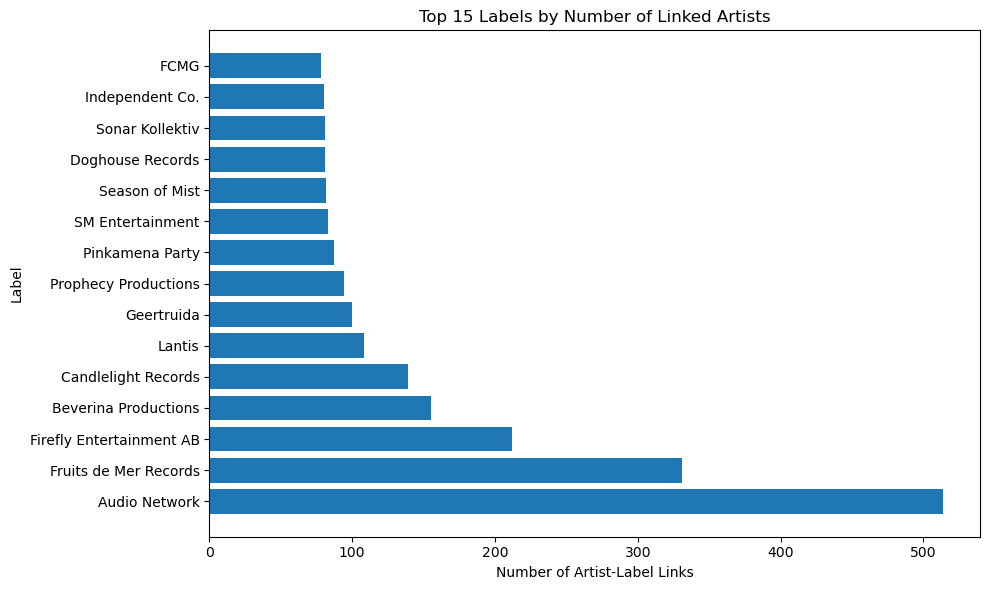

In [44]:
label_artist_pd = label_artist_counts.toPandas()

plt.figure(figsize=(10,6))
plt.barh(label_artist_pd["label"], label_artist_pd["artist_links"])
plt.title("Top 15 Labels by Number of Linked Artists")
plt.xlabel("Number of Artist-Label Links")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

**Artist Credit Histogram**

This histogram shows the distribution of the number of artists associated with each artist credit. We grouped the artist_credit_name table by artist_credit and counted how many artists were linked to each credit. The chart shows that the vast majority of artist credits involve a single artist, with significantly fewer credits involving multiple artists. This indicates that the dataset has far more solo artist credits than collaborations so collaborations will be rare in the dataset.

In [45]:
credit_sizes = dfs["artist_credit_name"].groupBy("artist_credit") \
    .agg(count("*").alias("num_artists"))
credit_sizes.show(5)

+-------------+-----------+
|artist_credit|num_artists|
+-------------+-----------+
|       967499|          1|
|       650352|          1|
|       879678|          2|
|        99239|          1|
|        99243|          1|
+-------------+-----------+
only showing top 5 rows



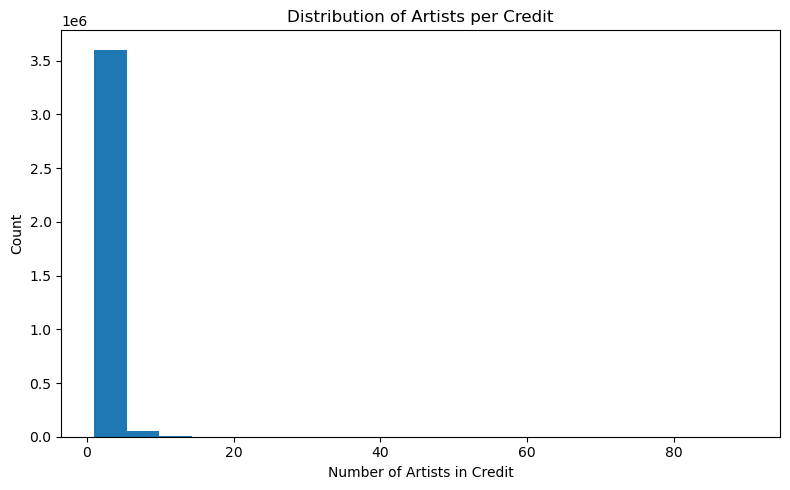

In [46]:
cred = credit_sizes.toPandas()

plt.figure(figsize=(8,5))

plt.hist(cred["num_artists"], bins=20)

plt.title("Distribution of Artists per Credit")
plt.xlabel("Number of Artists in Credit")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**Artist By Area Bar Chart**

The final bar plot was created to highlight the number of artists per country in the dataset. We focused on the top 15 countries and did so by joining the area and artist table. This plot shows that there is a large faction of artists that are from the United States. This shows that the dataset is heavily skewed to the US but there are other countries with a high amount of artists like Japan, Germany, and the United Kingdom.

In [47]:
artist_areas = dfs["artist"].join(
    dfs["area"],
    dfs["artist"].area == dfs["area"].id
).groupBy(
    dfs["area"].name.alias("area")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)

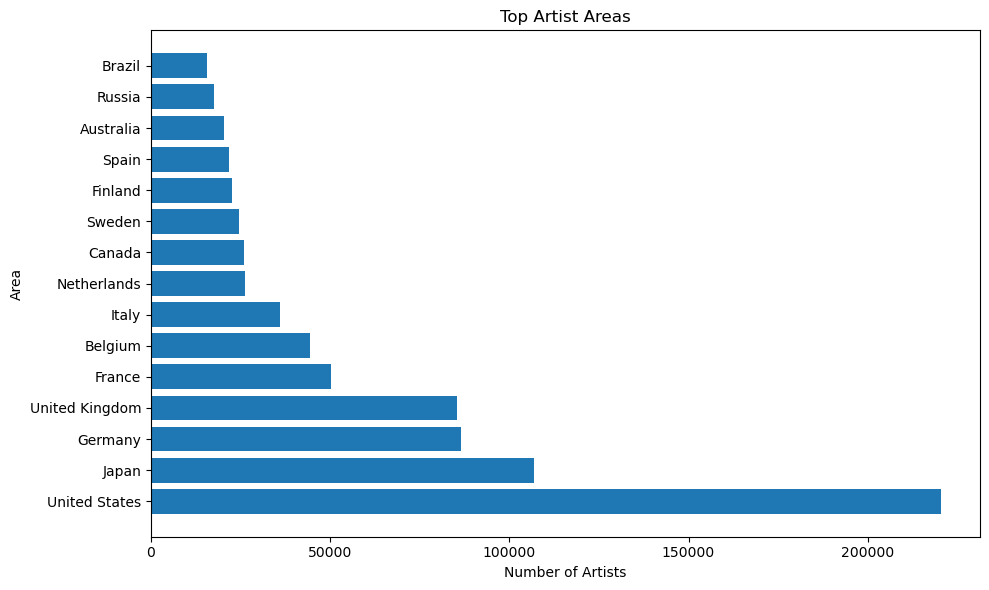

In [48]:
art_area = artist_areas.toPandas()

plt.figure(figsize=(10,6))
plt.barh(art_area["area"], art_area["count"])

plt.title("Top Artist Areas")
plt.xlabel("Number of Artists")
plt.ylabel("Area")
plt.tight_layout()
plt.show()

### Preprocessing Plan

Our first milestone will be to build a K-Nearest Neighbors which groups music based on its "DNA" (instruments, genres, labels, etc), so the first step will be to determine precisely which variables constitute part of music's DNA, and determining their relative importance. The next step will be to strip away unnecessary information, such as columns and tables we won't need (for example: "description" in the instruments table, since it contains natural language, will not be helpful for this problem). 

The data has a high volume of nulls. Depending on the data type these will need to be dealt with differently - for example, date columns might be left as nulls because imputing an "average" date probably doesn't make any sense. "Type" columns (which indicate something else for each table, but can refer to things like release type: original, bootleg, reissue, etc) have their most common entry set to 1, so nulls in that variable will likely be set to 1. There are also lots of entries in which most data is null - since the dataset is so large, some sets of rows might be filtered out completely.

We will primarily use SQL for preparing the data that we will operate on, then switch over to Python for filling nulls and cleaning. Some Spark transformations we may use include join, groupBy, collect_list, StringIndexer, OneHotEncoder, CountVectorizer, VectorAssembler, Normalizer, and filter.